In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv("Zomato-data-.csv")

In [5]:
df.columns = df.columns.str.strip()

In [6]:
# Clean target column
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].astype(str)
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].str.replace(",", "")
df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"], errors="coerce"
)

In [7]:
# Clean rate column
df["rate"] = df["rate"].astype(str)
df["rate"] = df["rate"].str.split("/").str[0]
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

In [8]:
# Remove missing values
df = df.dropna(subset=["approx_cost(for two people)", "rate", "votes"])

In [9]:
features = ["rate", "votes"]

X = df[features]
y = df["approx_cost(for two people)"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test)

In [13]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 200.84427401711983


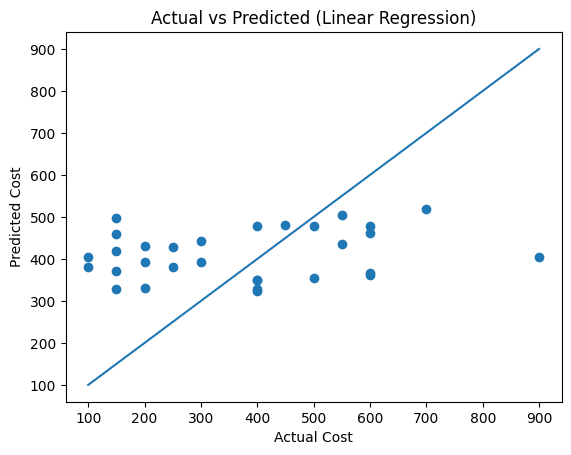

In [14]:
plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted (Linear Regression)")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()